# 01 — Fitting a Prism Spectrum

This notebook demonstrates the basic `jwspecfit` workflow:
1. Load a JWST NIRSpec PRISM spectrum from FITS
2. Fit all observable emission lines with BIC-based broad component selection
3. Inspect per-line results (flux, SNR, EW)
4. Plot the fit with Gaussian components (in Angstroms)
5. Save/load fit results and export line measurements
6. Interactive plotly plot for zooming into line profiles
7. Fit a restricted wavelength window

By default, `jwspecfit.fit_lines()` performs BIC model selection to
detect broad Balmer components (Hα, Hβ).  Set `mode="off"` for
narrow-only fitting.

The prism has wavelength-dependent resolution R(λ) ≈ 30–300, which
`jwspecfit` handles automatically from the FITS header.

In [1]:
import jwspecfit
import matplotlib.pyplot as plt

print(f"jwspecfit v{jwspecfit.__version__}")

jwspecfit v0.1.0


## Load the spectrum

The FITS file has a `SPEC1D` HDU with columns `wave` (µm), `flux` (µJy),
and `err` (µJy).  The grating is read from the header automatically.

In [2]:
spec = jwspecfit.read_fits("../../data/borg-v4_prism-clear_1747_732.spec.fits", z=8.22288)

print(f"Grating:    {spec.grating}")
print(f"Pixels:     {spec.n_pix}")
print(f"Wave range: {spec.wave_um.min():.3f} – {spec.wave_um.max():.3f} µm")

Grating:    PRISM
Pixels:     473
Wave range: 0.540 – 5.515 µm


## Quick look at the raw spectrum

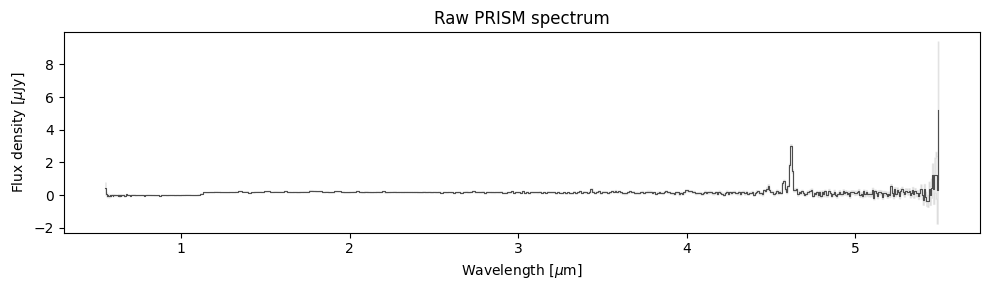

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
valid = spec.mask_valid()
ax.step(spec.wave_um[valid], spec.flux_ujy[valid], where="mid", lw=0.8, color="0.3")
ax.fill_between(
    spec.wave_um[valid],
    (spec.flux_ujy - spec.err_ujy)[valid],
    (spec.flux_ujy + spec.err_ujy)[valid],
    step="mid", alpha=0.15, color="0.5",
)
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"Flux density [$\mu$Jy]")
ax.set_title("Raw PRISM spectrum")
plt.tight_layout()

## Fit emission lines

A single call does everything: continuum subtraction, line detection,
Gaussian fitting, BIC-based broad component selection, and bootstrap
uncertainties.

Lines at or blueward of Lyman-α are automatically excluded (IGM-absorbed),
and the continuum is only fitted redward of the Lyman break.

The default `mode="auto"` checks whether broad Balmer components
(Hα, Hβ) improve the fit via the BIC.  If no broad component is
preferred, the result is equivalent to a narrow-only fit.

In [4]:
result = jwspecfit.fit_lines(spec, z=8.22288, deg=2)

print(f"Selected model: {result.selected_model}")
print(f"χ²/dof:         {result.chi2:.2f}")
print(f"Lines:          {', '.join(result.lines.keys())}")
print(f"BIC narrow:     {result.bic_narrow:.1f}")
print(f"BIC broad1:     {result.bic_broad1:.1f}")

Bootstrap (narrow): 100%|██████████| 1000/1000 [00:04<00:00, 209.26iter/s]

Selected model: narrow
χ²/dof:         1.13
Lines:          NV_doublet, CIV_doublet, CIII], OII_doublet, HDELTA, HGAMMA, OIII_4363, HBETA, OIII_4959, OIII_5007
BIC narrow:     9074.4
BIC broad1:     nan


## Per-line results

Each line has flux, bootstrap uncertainty, SNR, equivalent width,
centroid, and Gaussian width.

In [5]:
print(f"{'Line':<18s} {'Flux':>12s} {'Flux err':>12s} {'SNR':>8s} {'EW (Å)':>10s} {'σ (Å)':>8s}")
print("-" * 72)
for name, lr in result.lines.items():
    print(
        f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f} {lr.ew_A:10.1f} {lr.sigma_A:8.1f}"
    )

Line                       Flux     Flux err      SNR     EW (Å)    σ (Å)
------------------------------------------------------------------------
NV_doublet            1.237e-28    5.561e-29      2.2        0.0     70.7
CIV_doublet           3.071e-21    1.660e-18      0.0        0.0     85.9
CIII]                 1.733e-18    1.523e-18      1.1       10.1    106.1
OII_doublet           8.179e-19    4.908e-19      1.7       21.2     72.0
HDELTA                2.482e-19    4.144e-19      0.6        8.3     71.1
HGAMMA                6.002e-19    3.484e-19      1.7       23.5     75.3
OIII_4363             3.196e-19    3.219e-19      1.0       12.7     74.8
HBETA                 1.174e-18    4.395e-19      2.7       65.0     84.3
OIII_4959             2.167e-18    3.867e-19      5.6      128.5     87.3
OIII_5007             8.091e-18    4.261e-19     19.0      494.6     86.8


## Plot the fit

The plot shows data, continuum, total model, and individual Gaussian
components as filled curves.  The y-axis is scaled to the tallest
emission line so the lines are clearly visible.

/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


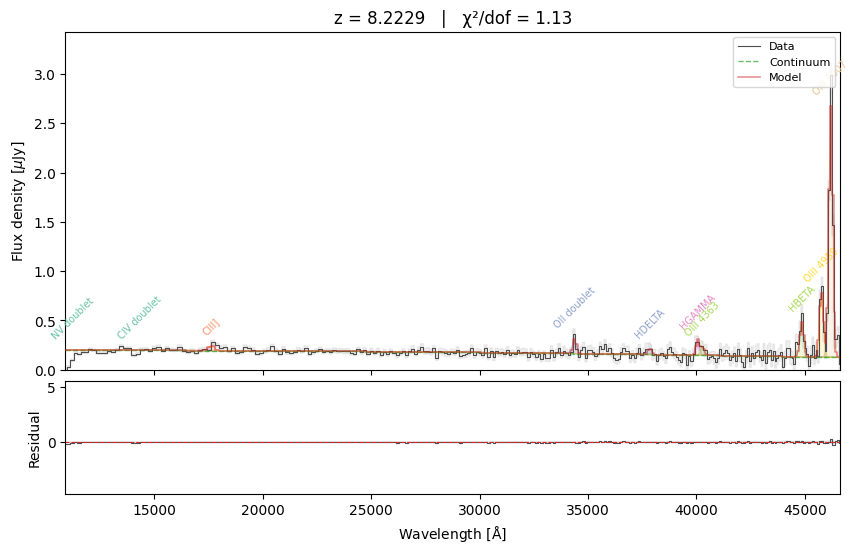

In [6]:
fig = jwspecfit.plot_fit(result)
plt.show()

In [7]:
fig_interactive = jwspecfit.plot_fit_interactive(result)
fig_interactive.show()

## Quick fit (narrow-only, analytic errors)

For fast exploration, set `mode="off"` to skip BIC broad-component
selection and `n_boot=0` for analytic error estimates.

In [8]:
result_fast = jwspecfit.fit_lines(spec, z=8.22288, n_boot=0, mode="off")

print(f"{'Line':<18s} {'Flux':>12s} {'Err (analytic)':>14s} {'SNR':>8s}")
print("-" * 56)
for name, lr in result_fast.lines.items():
    if lr.snr > 2:
        print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:14.3e} {lr.snr:8.1f}")

Line                       Flux Err (analytic)      SNR
--------------------------------------------------------
CIII]                 1.733e-18      4.482e-19      3.9
OII_doublet           8.179e-19      1.551e-19      5.3
HGAMMA                6.002e-19      1.367e-19      4.4
OIII_4363             3.196e-19      1.374e-19      2.3
HBETA                 1.174e-18      1.685e-19      7.0
OIII_4959             2.167e-18      1.615e-19     13.4
OIII_5007             8.091e-18      1.840e-19     44.0


## Fit specific lines only

You can restrict the fit to a subset of lines:

Bootstrap: 100%|██████████| 1000/1000 [00:00<00:00, 1025.45iter/s]
/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:313: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



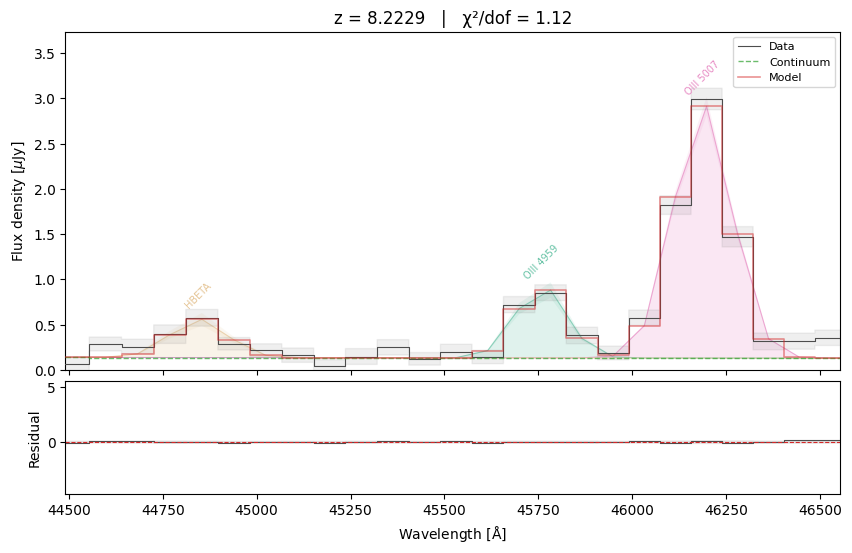

In [9]:
result_oiii = jwspecfit.fit_lines(
    spec, z=8.22288,
    lines=["OIII_4959", "OIII_5007", "HBETA"],
    mode="off",
)
fig = jwspecfit.plot_fit(result_oiii)
plt.show()

## Fit a wavelength window

Restrict the continuum and line fitting to a specific wavelength range
(in Angstroms). Useful for focusing on a single line complex.